✨ اقتراحات 'عهود' لك بناءً على: أبي أتعلم تصميم واجهات

📘 الدورة: مشروع تطبيقي في UX/UI
⏱️ المدة: 15 فيديو تعليمي | 🎓 المستوى: مبتدئ
----------------------------------------
📘 الدورة: Flutter 104
⏱️ المدة: 25 فيديو تعليمي | 🎓 المستوى: متوسط
----------------------------------------
📘 الدورة: البحث و التخطيط في تجربة المستخدم UX
⏱️ المدة: 14 فيديو تعليمي | 🎓 المستوى: مبتدئ
----------------------------------------


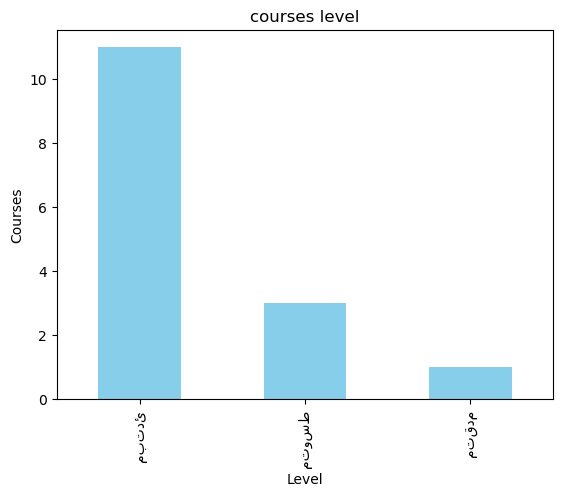

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
#read the informion
df = pd.read_csv('satr_data.csv')
#clean data (mix skills and des)
df['description'] =df['description'].fillna('')
df['skills'] = df['skills'].fillna('')
df[ 'combined' ] = df[ 'description' ] + " " + df[ 'skills' ] 
#bulld the sarch
tfidf = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b") 
tfidf_matrix = tfidf.fit_transform(df['combined'])

def recommend_me(user_input):
    query_vec = tfidf.transform([user_input])
    similarity = cosine_similarity(query_vec, tfidf_matrix).flatten()
    #best results
    top_indices = similarity.argsort()[-3:] [::-1] 
    print(f"✨ اقتراحات 'عهود' لك بناءً على: {user_input}\n")
    for i in top_indices:
        if similarity[i] > 0:
            print(f"📘 الدورة: {df.iloc[i]['course_name']}")
            print(f"⏱️ المدة: {df.iloc[i]['duration']} | 🎓 المستوى: {df.iloc[i]['level']}")
            print("-" * 40)

recommend_me("أبي أتعلم تصميم واجهات")
import matplotlib.pyplot as plt

# رسم بياني يوضح توزيع المستويات في الـ 15 دورة اللي جمعتيهم
df['level'].value_counts().plot(kind='bar', color='skyblue')
plt.title('courses level')
plt.xlabel('Level')
plt.ylabel('Courses')
plt.show()